In [236]:
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import ElasticNet, LinearRegression, Lasso
from sklearn.metrics import root_mean_squared_error
import xgboost as xgb

In [237]:
#Objectif : prédiction de la demande de remboursement pour un accident du travail
#On nous demande de prendre en compte l'inflation # ce n'est pas specifique à un pays en particulier (donc on ne peut pas avoir le pays en question) / la pays en question n'est pas dans les données - si l'inflation est importante, on peut exploiter les dates

In [238]:
dossier="/home/tiphainell/Documents/5.Direct Assurance/actuarial-loss-estimation"

In [239]:
# 54 000 lignes pour train (60% échantillon)
train=pd.read_csv(dossier+'/train.csv', sep=",")
#36 000 lignes (40%) pour le test
test=pd.read_csv(dossier+'/test.csv',sep=",")
#On doit fournir ClaimNumber et UltimateIncurredClaimCost
sample_submission=pd.read_csv(dossier+'/sample_submission.csv',sep=",")


In [240]:
train.describe(include=object)
#L'analyse des données montrent un âge moyen de 32 ans avec un écart type de 10 ans.
#La population n'a en moyenne pas d'enfant.
#Il y a des valeurs aberrantes sur le Weekly wages (1 dollar). Le salaire moyen par semaine est de 392 vec 248 d'écart type.
#En moyenne, la population travaille 5 jours
#Les heures travaillées sont autour de 38 heures
#Toutes ses varaibles ne semblent pas vraiement discriminantes


,ClaimNumber,DateTimeOfAccident,DateReported,Gender,MaritalStatus,PartTimeFullTime,ClaimDescription
count,54000,54000,54000,54000,53971,54000,54000
unique,54000,36673,6653,3,3,2,28114
top,WC8340658,1991-02-19T11:00:00Z,2001-03-29T00:00:00Z,M,S,F,SLIPPED ON ROLLER TENDONITIS RIGHT SHOULDER
freq,1,9,25,41660,26161,49112,289


In [241]:
train['Gender'].value_counts()

Gender
M    41660
F    12338
U        2
Name: count, dtype: int64

In [242]:
train['MaritalStatus'].value_counts()

MaritalStatus
S    26161
M    22516
U     5294
Name: count, dtype: int64

In [243]:
train["PartTimeFullTime"].value_counts()

PartTimeFullTime
F    49112
P     4888
Name: count, dtype: int64

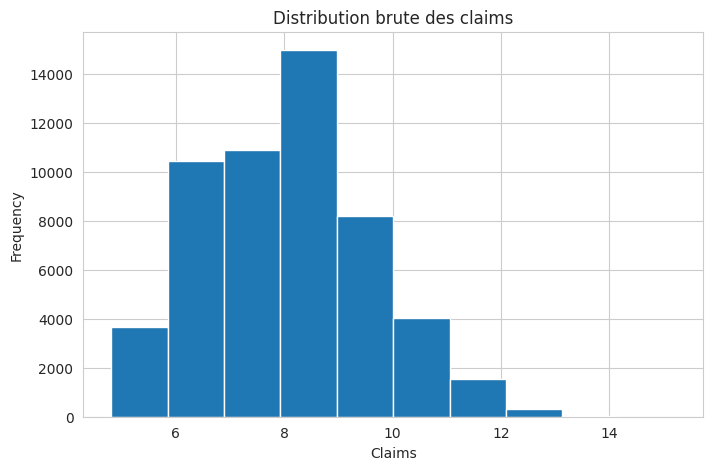

In [244]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(np.log1p(train[features_y]))
plt.title("Distribution brute des claims")
plt.xlabel("Claims")
plt.ylabel("Frequency")
plt.show()

In [245]:
#Traitement des inputs, récupération des noms des colonnes
features=train.columns.tolist()
features_y=features.pop()

In [246]:
#je vais convertir les dates
train["DateTimeOfAccident"] = pd.to_datetime(train["DateTimeOfAccident"])
train["year"] = train["DateTimeOfAccident"].dt.year
train["month"] = train["DateTimeOfAccident"].dt.month
train["day"] = train["DateTimeOfAccident"].dt.day
train["hour"] = train["DateTimeOfAccident"].dt.hour
train["minute"] = train["DateTimeOfAccident"].dt.minute
train["week"] = train["DateTimeOfAccident"].dt.isocalendar().week

#je veux créer des bins pour les heures travaillées
#il y a des valeurs aberrantes dans le data set (640 heures travaillées)
train_encoded = pd.get_dummies(train, columns=["Gender"], drop_first=True)
train_encoded = pd.get_dummies(train_encoded, columns=["MaritalStatus"], drop_first=True)
train_encoded = pd.get_dummies(train_encoded, columns=["PartTimeFullTime"], drop_first=True)
train=train_encoded


train_encoded 

,ClaimNumber,DateTimeOfAccident,DateReported,Age,DependentChildren,DependentsOther,WeeklyWages,HoursWorkedPerWeek,DaysWorkedPerWeek,ClaimDescription,...,month,day,hour,minute,week,Gender_M,Gender_U,MaritalStatus_S,MaritalStatus_U,PartTimeFullTime_P
0,WC8285054,2002-04-09 07:00:00+00:00,2002-07-05T00:00:00Z,48,0,0,500.00,38.0,5,LIFTING TYRE INJURY TO RIGHT ARM AND WRIST INJURY,...,4,9,7,0,15,True,False,False,False,False
1,WC6982224,1999-01-07 11:00:00+00:00,1999-01-20T00:00:00Z,43,0,0,509.34,37.5,5,STEPPED AROUND CRATES AND TRUCK TRAY FRACTURE ...,...,1,7,11,0,1,False,False,False,False,False
2,WC5481426,1996-03-25 00:00:00+00:00,1996-04-14T00:00:00Z,30,0,0,709.10,38.0,5,CUT ON SHARP EDGE CUT LEFT THUMB,...,3,25,0,0,13,True,False,False,True,False
3,WC9775968,2005-06-22 13:00:00+00:00,2005-07-22T00:00:00Z,41,0,0,555.46,38.0,5,DIGGING LOWER BACK LOWER BACK STRAIN,...,6,22,13,0,25,True,False,True,False,False
4,WC2634037,1990-08-29 08:00:00+00:00,1990-09-27T00:00:00Z,36,0,0,377.10,38.0,5,REACHING ABOVE SHOULDER LEVEL ACUTE MUSCLE STR...,...,8,29,8,0,35,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53995,WC9370727,2004-08-21 18:00:00+00:00,2004-09-08T00:00:00Z,32,0,0,500.00,38.0,5,STRUCK KNIFE LACERATED LEFT MIDDLE FINGER LEFT...,...,8,21,18,0,34,False,False,True,False,False
53996,WC8396269,2002-04-28 09:00:00+00:00,2002-09-03T00:00:00Z,20,0,0,500.00,40.0,5,LEFT HAND LACERATION LEFT SIDE BACK AND LEFT LEG,...,4,28,9,0,17,False,False,True,False,False
53997,WC3609528,1992-02-28 09:00:00+00:00,1992-03-18T00:00:00Z,19,0,0,283.00,40.0,5,METAL SLIPPED ACROSS METAL CUT FINGER,...,2,28,9,0,9,True,False,True,False,False
53998,WC5038565,1995-01-10 07:00:00+00:00,1995-01-31T00:00:00Z,24,0,0,200.00,38.0,5,BURN WHILST USING SPANNER LACERATION RIGHT MID...,...,1,10,7,0,2,True,False,True,False,False


In [247]:
#je veux reseparer mon train en train et val
#question que je me suis posée : est_ce que c'est possible qu'il y ait la même personne dans le dataset? je fais l'hypothèse que toutes les claims viennent de personnes différentes

In [248]:
train["HoursWorkedPerWeek"]

0        38.0
1        37.5
2        38.0
3        38.0
4        38.0
         ... 
53995    38.0
53996    40.0
53997    40.0
53998    38.0
53999    38.0
Name: HoursWorkedPerWeek, Length: 54000, dtype: float64

In [249]:

features_x=train.columns.tolist()
features_x.pop(0)
features_x.remove("DateTimeOfAccident")
features_x.remove("UltimateIncurredClaimCost")
features_x.remove("DateReported")
features_x.remove("ClaimDescription")

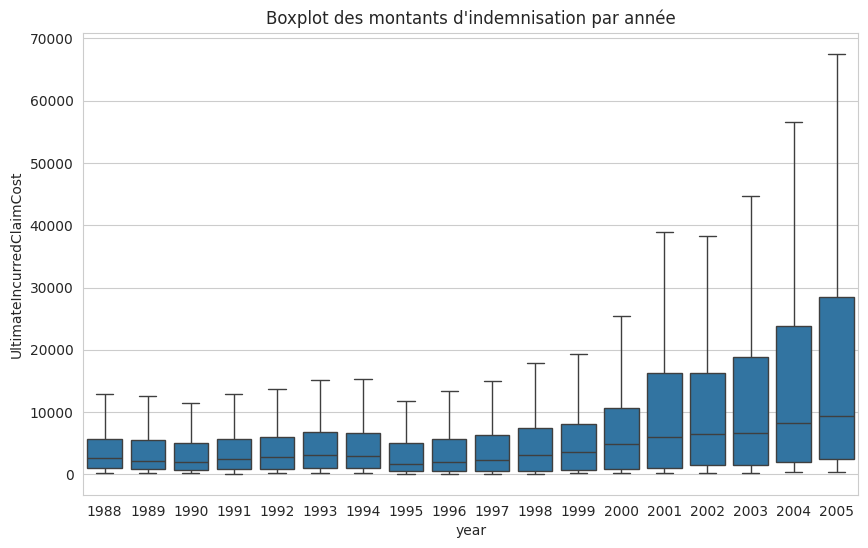

In [250]:

#montant d'indemnisation selon les années
#on voit l'effet de l'inflation sur les années

plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x="year", y=features_y,showfliers=False)

plt.title("Boxplot des montants d'indemnisation par année")
plt.show()

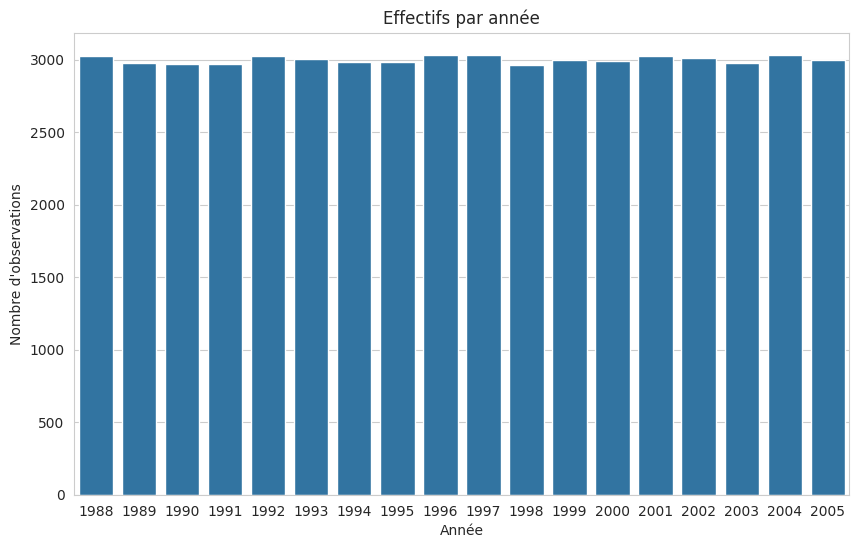

In [251]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train, x="year")

plt.title("Effectifs par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'observations")

plt.show()
#dataset équilibré

In [252]:
#Indemnisation par genre
 
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x="Gender", y=features_y,showfliers=False)

plt.title("Boxplot des montants d'indemnisation par genre")
plt.show()
#influence du genre/ que veut dire U?

ValueError: Could not interpret value `Gender` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

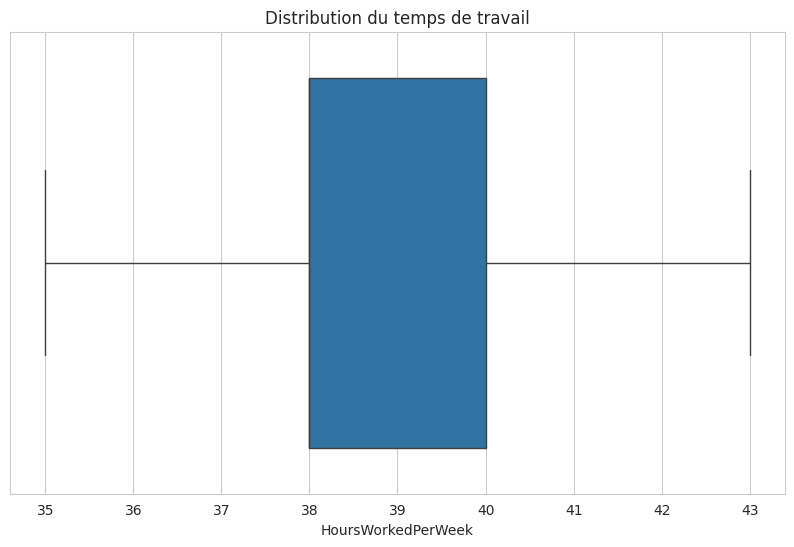

In [253]:
#distribution du temps de travail
 
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x="HoursWorkedPerWeek",showfliers=False)

plt.title("Distribution du temps de travail")
plt.show()
#influence du genre

In [262]:

# database=train
# train=database[database["year"]<2001]
# val=database[database["year"]>=2001]
# X_train=train[features_x]
# X_val=val[features_x]
# y_train=train[features_y]
# y_val=val[features_y]

X_train, X_val, y_train, y_val=train_test_split(train[features_x], train[features_y], test_size=0.2,random_state=42)

In [263]:
features_y

'UltimateIncurredClaimCost'

In [264]:
database

,ClaimNumber,DateTimeOfAccident,DateReported,Age,DependentChildren,DependentsOther,WeeklyWages,HoursWorkedPerWeek,DaysWorkedPerWeek,ClaimDescription,...,month,day,hour,minute,week,Gender_M,Gender_U,MaritalStatus_S,MaritalStatus_U,PartTimeFullTime_P
0,WC8285054,2002-04-09 07:00:00+00:00,2002-07-05T00:00:00Z,48,0,0,500.00,38.0,5,LIFTING TYRE INJURY TO RIGHT ARM AND WRIST INJURY,...,4,9,7,0,15,True,False,False,False,False
1,WC6982224,1999-01-07 11:00:00+00:00,1999-01-20T00:00:00Z,43,0,0,509.34,37.5,5,STEPPED AROUND CRATES AND TRUCK TRAY FRACTURE ...,...,1,7,11,0,1,False,False,False,False,False
2,WC5481426,1996-03-25 00:00:00+00:00,1996-04-14T00:00:00Z,30,0,0,709.10,38.0,5,CUT ON SHARP EDGE CUT LEFT THUMB,...,3,25,0,0,13,True,False,False,True,False
3,WC9775968,2005-06-22 13:00:00+00:00,2005-07-22T00:00:00Z,41,0,0,555.46,38.0,5,DIGGING LOWER BACK LOWER BACK STRAIN,...,6,22,13,0,25,True,False,True,False,False
4,WC2634037,1990-08-29 08:00:00+00:00,1990-09-27T00:00:00Z,36,0,0,377.10,38.0,5,REACHING ABOVE SHOULDER LEVEL ACUTE MUSCLE STR...,...,8,29,8,0,35,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53995,WC9370727,2004-08-21 18:00:00+00:00,2004-09-08T00:00:00Z,32,0,0,500.00,38.0,5,STRUCK KNIFE LACERATED LEFT MIDDLE FINGER LEFT...,...,8,21,18,0,34,False,False,True,False,False
53996,WC8396269,2002-04-28 09:00:00+00:00,2002-09-03T00:00:00Z,20,0,0,500.00,40.0,5,LEFT HAND LACERATION LEFT SIDE BACK AND LEFT LEG,...,4,28,9,0,17,False,False,True,False,False
53997,WC3609528,1992-02-28 09:00:00+00:00,1992-03-18T00:00:00Z,19,0,0,283.00,40.0,5,METAL SLIPPED ACROSS METAL CUT FINGER,...,2,28,9,0,9,True,False,True,False,False
53998,WC5038565,1995-01-10 07:00:00+00:00,1995-01-31T00:00:00Z,24,0,0,200.00,38.0,5,BURN WHILST USING SPANNER LACERATION RIGHT MID...,...,1,10,7,0,2,True,False,True,False,False


In [265]:

model=xgb.XGBRegressor(n_estimators=10,max_depth=10)

X_train

,Age,DependentChildren,DependentsOther,WeeklyWages,HoursWorkedPerWeek,DaysWorkedPerWeek,InitialIncurredCalimsCost,year,month,day,hour,minute,week,Gender_M,Gender_U,MaritalStatus_S,MaritalStatus_U,PartTimeFullTime_P
5688,34,0,0,200.00,38.0,5,350,1996,6,25,11,0,26,True,False,False,False,False
40513,40,0,0,431.40,38.0,5,65000,2003,2,17,8,0,8,True,False,False,True,False
17163,26,0,0,435.70,40.0,5,6000,1993,5,4,11,0,18,True,False,True,False,False
39180,34,0,0,826.92,40.0,5,7800,1995,10,17,10,0,42,True,False,False,False,False
7905,24,0,0,728.05,40.0,5,25000,2000,3,2,9,0,9,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,20,0,0,381.30,38.0,5,7500,1995,9,21,8,0,38,True,False,False,False,False
44732,54,0,0,350.00,37.5,5,420,1988,7,6,11,0,27,False,False,False,False,False
38158,42,0,0,554.55,40.0,5,2600,1989,5,11,15,0,19,True,False,False,False,False
860,22,0,0,200.00,38.0,5,500,2001,11,16,10,0,46,True,False,True,False,False


In [266]:
#p.log1p(y_train)
trained_model=model.fit(X_train, np.log1p(y_train))

In [267]:
train["HoursWorkedPerWeek"].max()


np.float64(640.0)

In [268]:
y_predict=trained_model.predict(X_val)

In [269]:
rmse=root_mean_squared_error(np.log1p(y_val),y_predict)
#rmse=root_mean_squared_error(y_val,y_predict)
rmse

0.7281281175823399

In [270]:
root_mean_squared_error(y_val,np.expm1(y_predict))

25961.0041480705

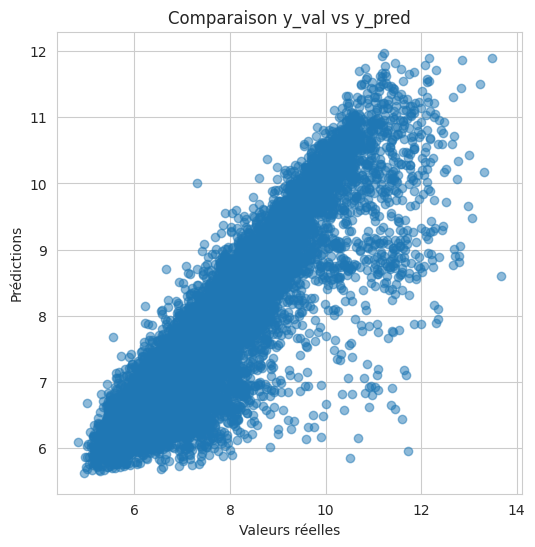

In [271]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(np.log1p(y_val), y_predict, alpha=0.5)

#plt.plot([y_val.min(), y_val.max()],
#         [y_val.min(), y_val.max()],
#         color="red")

plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Comparaison y_val vs y_pred")
plt.show()

In [272]:
import pandas as pd

results = pd.DataFrame({
    "y_true": y_val,
    "y_pred": np.expm1(y_predict)
})

print(results.head())
results["error"] = results["y_pred"] - results["y_true"]
results["abs_error"] = results["error"].abs()

print(results.sort_values("abs_error", ascending=False).head(10))

            y_true       y_pred
30246  4186.838233  7607.564941
34164  1805.475703   880.765930
40692  2679.339455  3275.806152
28724   525.627329   725.948914
28097  3859.038178  2009.590088
            y_true         y_pred          error      abs_error
23036  865770.6486    5443.658203 -860326.990397  860326.990397
25148  608650.4259   26261.207031 -582389.218869  582389.218869
28959  713784.0636  145940.437500 -567843.626100  567843.626100
1811   558408.9616   98938.140625 -459470.820975  459470.820975
46554  469915.2680   13040.739258 -456874.528742  456874.528742
49409  437090.9229   15656.999023 -421433.923877  421433.923877
41634  443427.7888   33733.816406 -409693.972394  409693.972394
51437  368742.9788    8514.477539 -360228.501261  360228.501261
24332  358905.5532    6706.194336 -352199.358864  352199.358864
6381   357216.5404    7305.806641 -349910.733759  349910.733759
